In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# 한글 폰트 설정 (windows)
plt.rcParams['font.family'] = 'Malgun Gothic'

df = pd.read_csv('dataset\heart_2020_cleaned.csv\heart_2020_cleaned.csv')
print(df.shape)

#df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

# df['Diabetic'] = df['Diabetic'].map({
#     'Yes': 'Yes',
#     'Yes (during pregnancy)': 'Yes',
#     'No': 'No',
#     'No, borderline diabetes': 'No'
# })

(319795, 18)


In [9]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [5]:
print(df.isnull().sum().sum())
print(df.duplicated().sum()) 

0
18078


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [7]:
df.select_dtypes(include='object').nunique() # 범주형 변수 카디널리티

HeartDisease         2
Smoking              2
AlcoholDrinking      2
Stroke               2
DiffWalking          2
Sex                  2
AgeCategory         13
Race                 6
Diabetic             4
PhysicalActivity     2
GenHealth            5
Asthma               2
KidneyDisease        2
SkinCancer           2
dtype: int64

In [14]:
print(f'범주형 변수 : {df.select_dtypes(include="object").columns}')

범주형 변수 : Index(['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
       'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
       'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')


# target

In [21]:
df.value_counts('HeartDisease')

HeartDisease
0    292422
1     27373
Name: count, dtype: int64

Text(0.5, 1.0, 'Heart Disease Distribution')

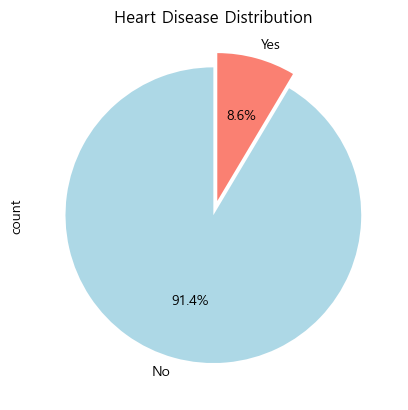

In [10]:
df['HeartDisease'].value_counts().plot.pie(autopct='%1.1f%%',
                                            startangle=90, colors=['lightblue', 'salmon'],
                                            explode=(0, 0.1))
plt.title('Heart Disease Distribution')

# 범주형 변수

In [19]:
obj_df = df.select_dtypes(include='object')
obj_col = obj_df.columns.tolist()
for col in obj_col:
    print('-------------------------')
    print(f'{col}: {obj_df[col].unique()} , n={obj_df[col].nunique()}')
    

-------------------------
HeartDisease: ['No' 'Yes'] , n=2
-------------------------
Smoking: ['Yes' 'No'] , n=2
-------------------------
AlcoholDrinking: ['No' 'Yes'] , n=2
-------------------------
Stroke: ['No' 'Yes'] , n=2
-------------------------
DiffWalking: ['No' 'Yes'] , n=2
-------------------------
Sex: ['Female' 'Male'] , n=2
-------------------------
AgeCategory: ['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29'] , n=13
-------------------------
Race: ['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic'] , n=6
-------------------------
Diabetic: ['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)'] , n=4
-------------------------
PhysicalActivity: ['Yes' 'No'] , n=2
-------------------------
GenHealth: ['Very good' 'Fair' 'Good' 'Poor' 'Excellent'] , n=5
-------------------------
Asthma: ['Yes' 'No'] , n=2
-------------------------
KidneyDisease: ['No' 'Yes'] , n=2
-----------

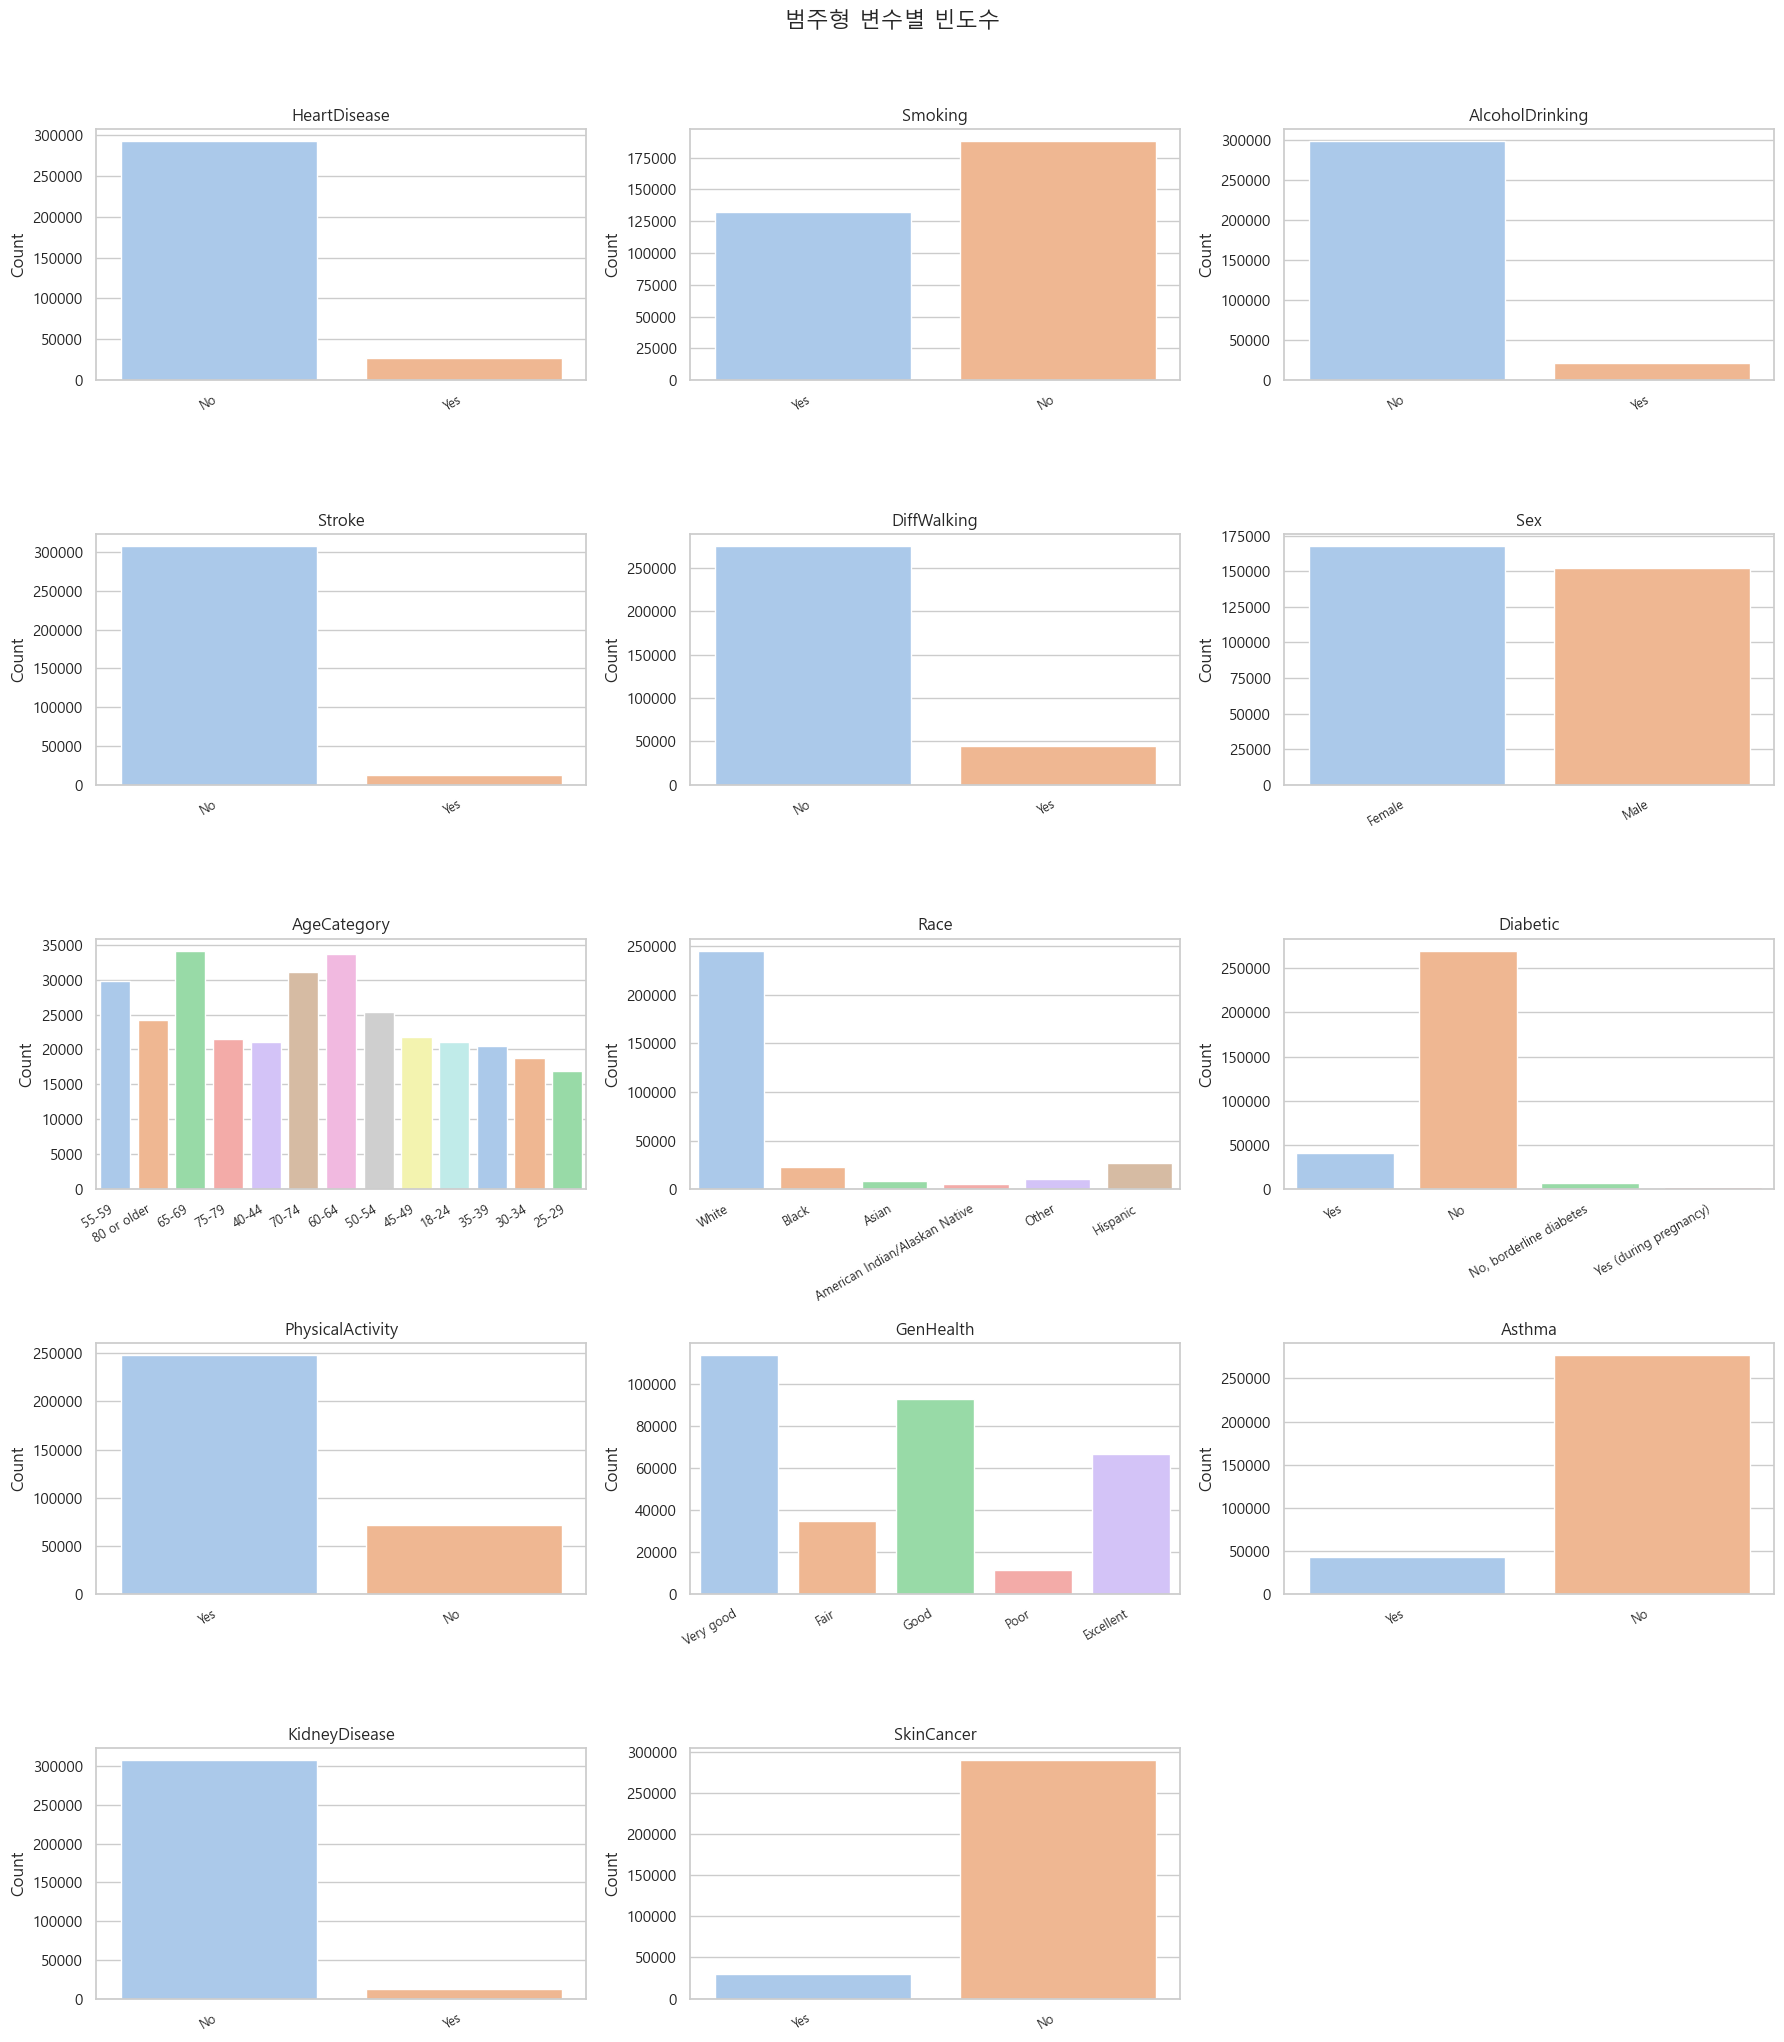

In [20]:
import math
n_cols = 3   # 가로로 3개씩
n_rows = math.ceil(len(obj_df.columns) / n_cols)

plt.figure(figsize=(n_cols * 6, n_rows * 4))
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})


for i, col in enumerate(obj_df.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    order = obj_df[col].value_counts().index
    sns.countplot(data=obj_df, x=col, hue=col, palette="pastel", legend=False)
    plt.title(col, fontsize=12)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha='right', fontsize=9)

plt.suptitle("범주형 변수별 빈도수", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [4]:
# 비율계산을 위해 인코딩
df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

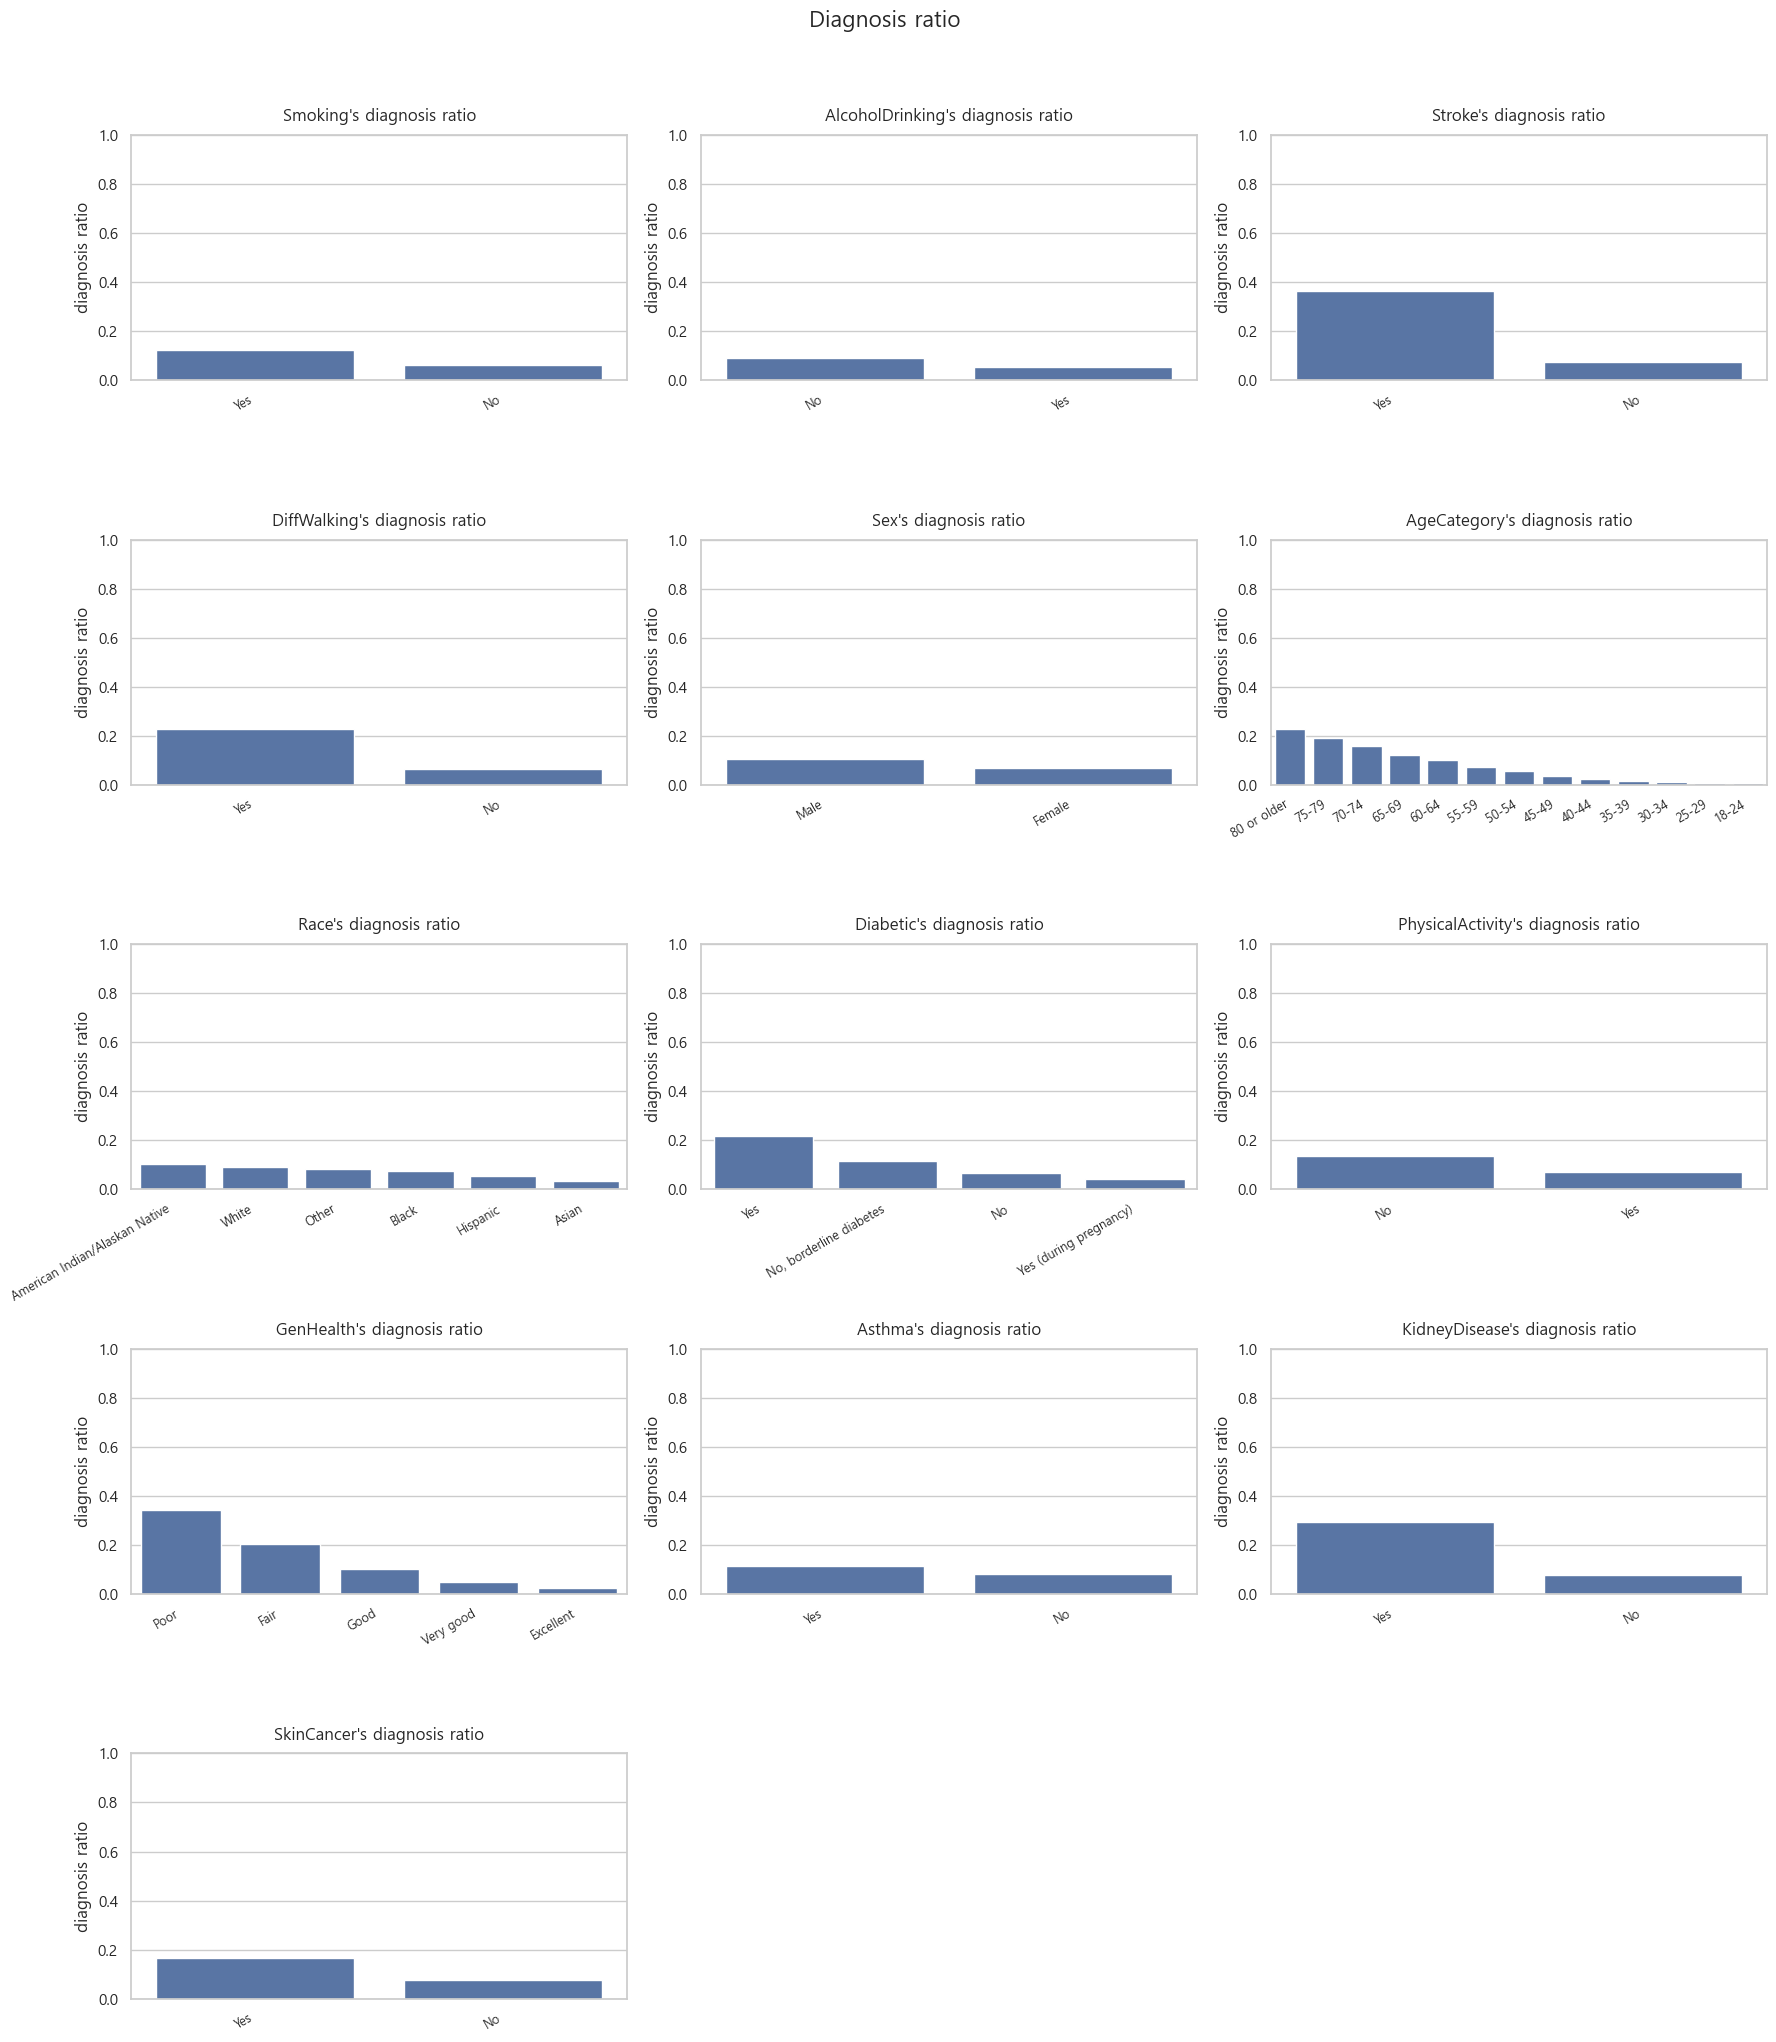

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math




# Diagnosis 포함된 전체 df에서 범주형 변수만 추출
cat_cols = obj_df.columns.drop('HeartDisease')  # 'HeartDisease' 제외
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Diagnosis=1 비율 계산
    rate_df = (
        df.groupby(col)["HeartDisease"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(
        data=rate_df,
        x=col,
        y='HeartDisease',
    )

    plt.title(f"{col}'s diagnosis ratio", fontsize=12, pad=10)
    plt.xlabel("")
    plt.ylabel("diagnosis ratio")
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.ylim(0, 1)

plt.suptitle("Diagnosis ratio", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# 카이제곱 검정

In [33]:
df.select_dtypes("object").columns

Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex',
       'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
# AgeCategory, GenHealth, Diabetic (제외 카디널리니가 높은 변수들 제외)
cols = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex' ,
        'PhysicalActivity', 'Asthma', 'KidneyDisease',
       'SkinCancer','Diabetic']
results = []

for col in cols:
    # 교차표 만들기
    table = pd.crosstab(df[col], df['HeartDisease'])
    
    # 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(table)
    
    # 기대빈도 조건 확인 (가정 검토)
    low_expected = (expected < 5).sum().sum()
    total_cells = expected.size
    low_ratio = low_expected / total_cells
    
    results.append({
        'Variable': col,
        'Chi2': round(chi2, 3),
        'df': dof,
        'p-value': round(p, 5),
        'Low Expected (<5)': f"{low_expected}/{total_cells} ({low_ratio:.1%})",
        'Significant': '✅ Yes (p<0.05)' if p < 0.001 else '❌ No'
    })

# 결과 요약표
result_df = pd.DataFrame(results)
print(result_df)


           Variable       Chi2  df  p-value Low Expected (<5)     Significant
0           Smoking   3713.033   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
1   AlcoholDrinking    328.649   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
2            Stroke  12386.489   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
3       DiffWalking  12951.153   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
4               Sex   1568.307   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
5  PhysicalActivity   3199.008   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
6            Asthma    548.851   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
7     KidneyDisease   6739.226   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
8        SkinCancer   2783.641   1      0.0        0/4 (0.0%)  ✅ Yes (p<0.05)
9          Diabetic  10959.861   3      0.0        0/8 (0.0%)  ✅ Yes (p<0.05)


# 연속형변수

In [42]:
con_df = df.select_dtypes(include=['float64'])
print(con_df.columns)
con_df.describe()

Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], dtype='object')


,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


In [43]:
# 연속형 변수 선택
con_df = df.select_dtypes(include='float64')

# 타깃 지정
target = 'HeartDisease'

# 평균 계산
mean_summary = (
    df.groupby(target)[con_df.columns]
    .mean()
    .T  # 변수 기준으로 전치
    .rename(columns={0: 'Mean(HeartDisease=No)', 1: 'Mean(HeartDisease=Yes)'})
)

# 평균 차이 계산
mean_summary['Mean Diff (Yes - No)'] = mean_summary['Mean(HeartDisease=Yes)'] - mean_summary['Mean(HeartDisease=No)']
mean_summary.round(3)


HeartDisease,Mean(HeartDisease=No),Mean(HeartDisease=Yes),Mean Diff (Yes - No)
BMI,28.225,29.402,1.177
PhysicalHealth,2.956,7.808,4.852
MentalHealth,3.829,4.642,0.813
SleepTime,7.093,7.136,0.043


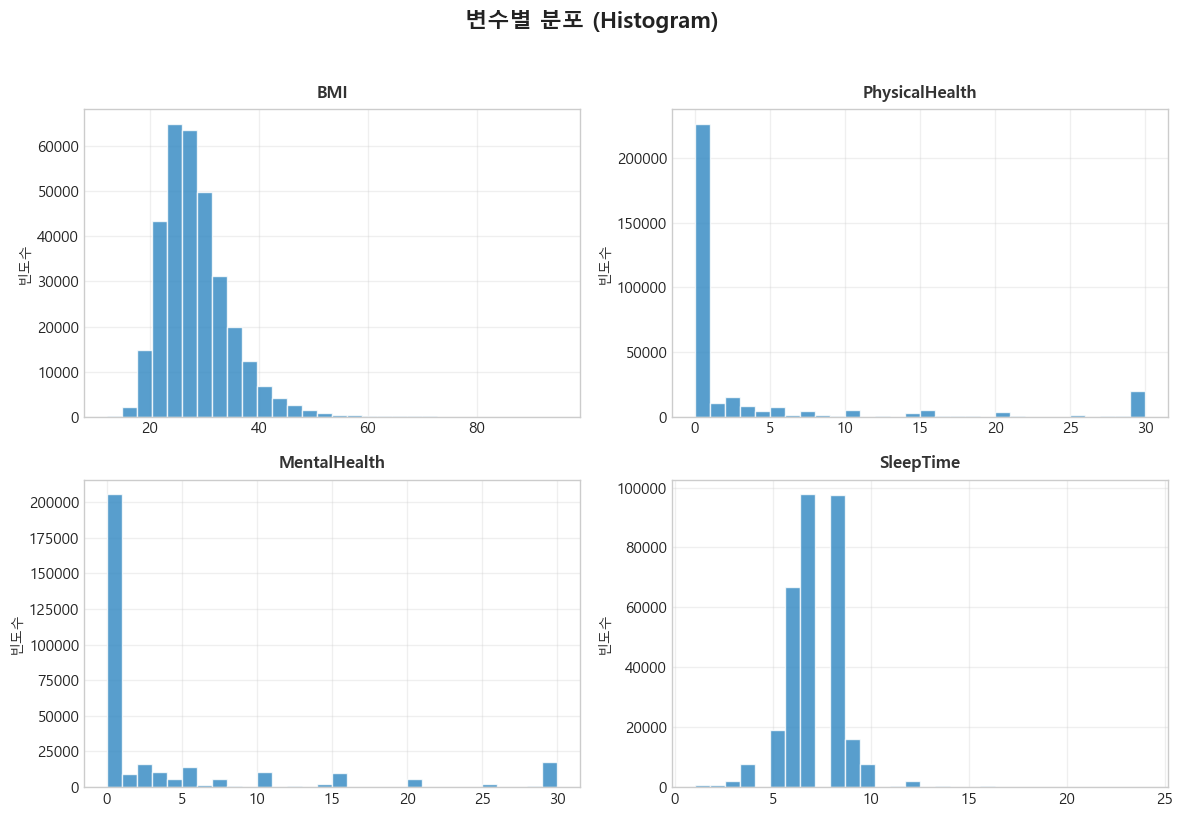

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 스타일 적용
plt.style.use('seaborn-v0_8-whitegrid')

# 폰트 및 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전체 히스토그램
axes = con_df.hist(
    bins=30,
    figsize=(12, 8),
    edgecolor='white',
    color='#2E86C1',   # 파란색 계열
    alpha=0.8,
)

# 각 서브플롯 제목·축 정리
for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold', color='#333333', pad=8)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel('빈도수', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('변수별 분포 (Histogram)', fontsize=16, fontweight='bold', color='#222222', y=1.02)
plt.tight_layout()
plt.show()


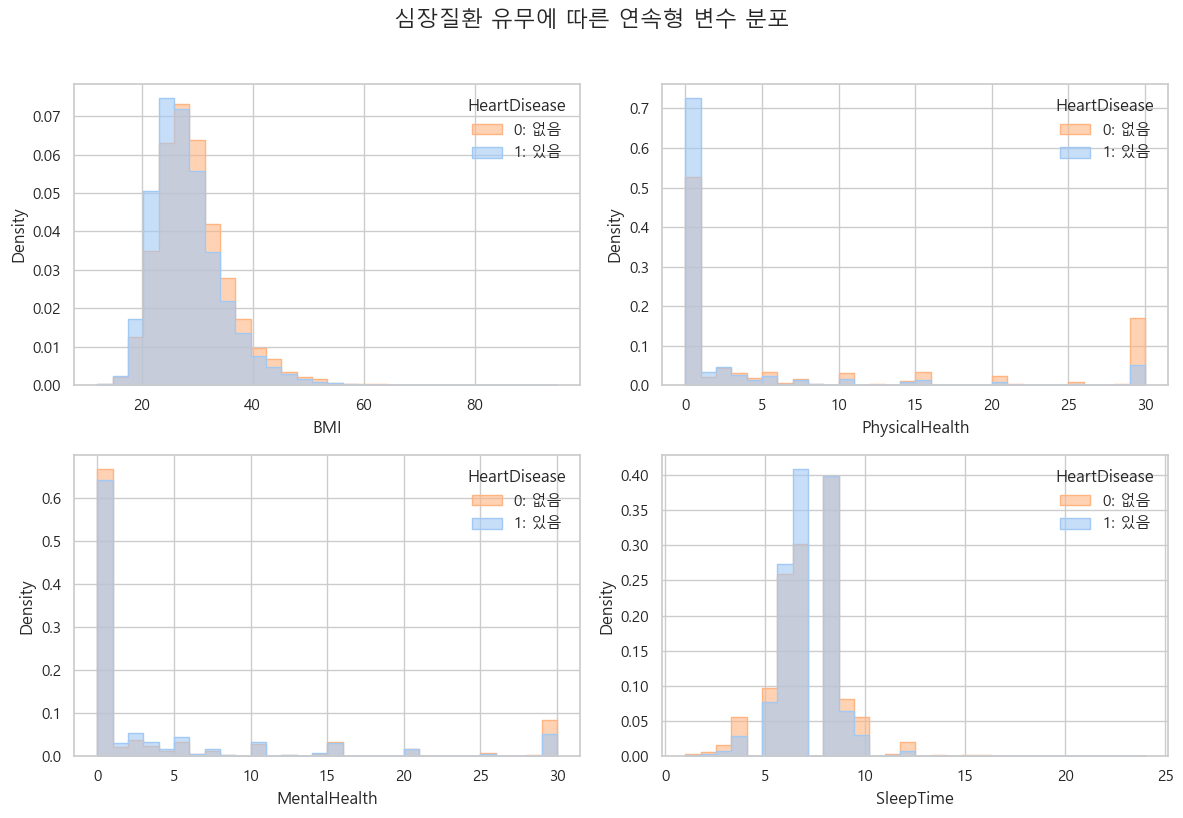

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🔹 예시 가정
# df: 전체 데이터프레임
# HeartDisease: 타겟 (0/1)
# 연속형 변수 4개
num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

# 🔹 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

n_cols = 2
n_rows = len(num_cols) // n_cols + (len(num_cols) % n_cols > 0)
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(
        data=df,
        x=col,
        hue="HeartDisease",
        bins=30,
        palette="pastel",
        element="step",
        stat="density",      # 밀도 기준 (비율 비교에 유리)
        common_norm=False,   # 클래스별 정규화 X
        alpha=0.6
    )
    #plt.title(f"{col} 분포 (HeartDisease별)", fontsize=13, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend(title="HeartDisease", labels=["0: 없음", "1: 있음"])

plt.suptitle("심장질환 유무에 따른 연속형 변수 분포", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [46]:
con_df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


# BMI

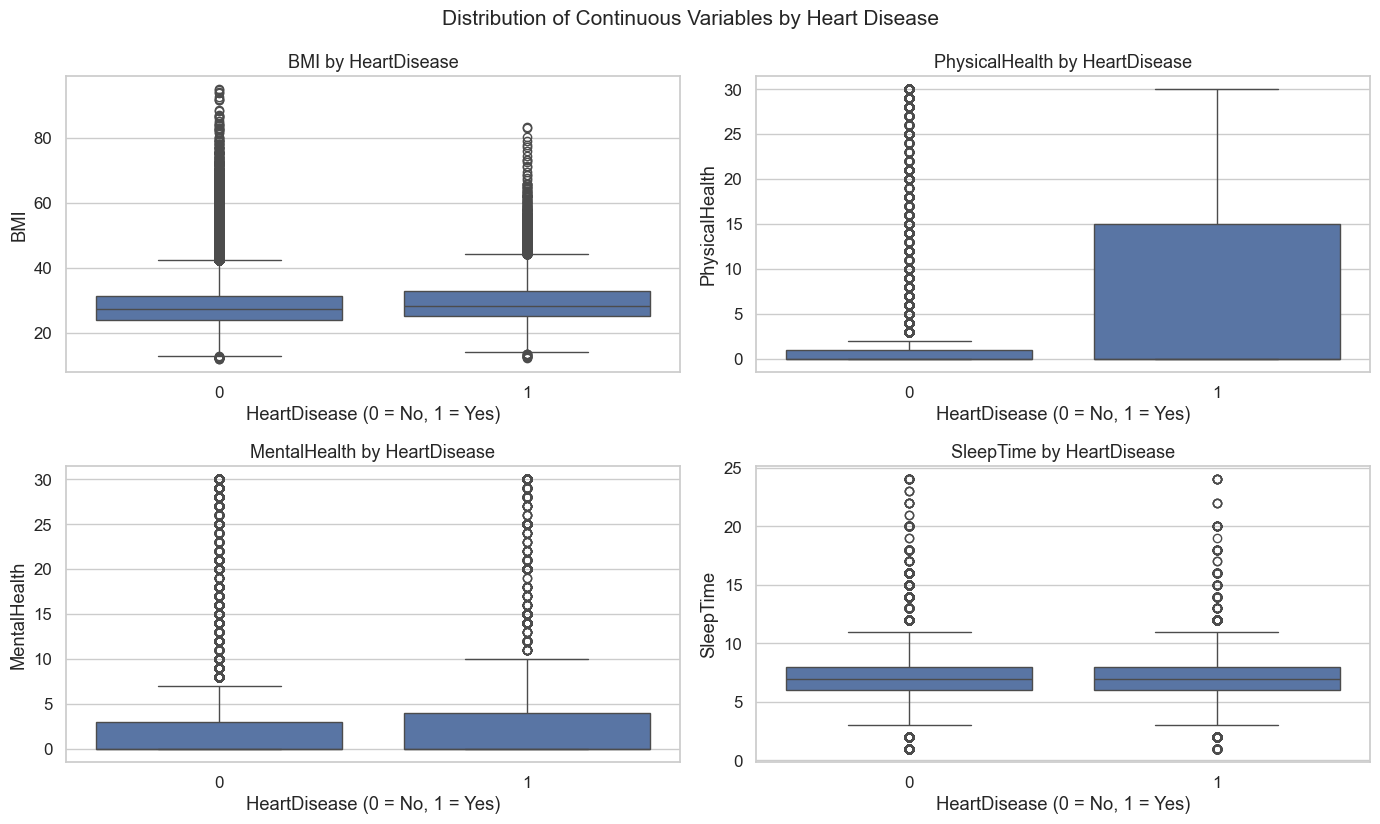

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 연속형 변수 선택
con_vars = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

plt.figure(figsize=(14, 8))
sns.set(style="whitegrid", font_scale=1.1)

for i, col in enumerate(con_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df,
        x='HeartDisease',
        y=col)
    plt.title(f'{col} by HeartDisease', fontsize=13)
    plt.xlabel('HeartDisease (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()

plt.suptitle('Distribution of Continuous Variables by Heart Disease', fontsize=15, y=1.03)
plt.show();


# 평균 비교

In [50]:
# 평균비교 - t- test
import pandas as pd
import numpy as np
from scipy import stats

# 연속형 변수 선택
con_df = df.select_dtypes(include='float64')
target = 'HeartDisease'
features = [c for c in con_df.columns if c != target]

results = []

for col in features:
    # 두 그룹 나누기
    group1 = df.loc[df[target] == 1, col].dropna()
    group0 = df.loc[df[target] == 0, col].dropna()
    
    # ------------------------
    # (1) 그룹별 평균 출력
    # ------------------------
    mean1 = group1.mean()
    mean0 = group0.mean()
    diff = mean1 - mean0
    
    # ------------------------
    # (2) 정규성 검정 (Shapiro-Wilk)
    # 표본 5000 이상이면 p<0.05 나오는 경향 있으므로 참고용
    # ------------------------
    p_shapiro1 = stats.shapiro(group1.sample(min(5000, len(group1))))[1] if len(group1) >= 3 else np.nan
    p_shapiro0 = stats.shapiro(group0.sample(min(5000, len(group0))))[1] if len(group0) >= 3 else np.nan
    
    norm_ok = (p_shapiro1 > 0.05) and (p_shapiro0 > 0.05)
    
    # ------------------------
    # (3) 등분산성 검정 (Levene test)
    # ------------------------
    p_levene = stats.levene(group1, group0)[1]
    equal_var = p_levene > 0.05
    
    # ------------------------
    # (4) t-test (가정에 따라)
    # ------------------------
    t_stat, p_ttest = stats.ttest_ind(group1, group0, equal_var=equal_var)
    
    results.append({
        'Variable': col,
        'Mean(HeartDisease=1)': round(mean1, 3),
        'Mean(HeartDisease=0)': round(mean0, 3),
        'Mean Diff': round(diff, 3),
        'Normality OK?': norm_ok,
        'Equal Var?': equal_var,
        'p (t-test)': round(p_ttest, 5),
        'Significant': '✅ Yes (p<0.05)' if p_ttest < 0.05 else '❌ No'
    })

# 결과표 보기
result_df = pd.DataFrame(results)
print(result_df)


         Variable  Mean(HeartDisease=1)  Mean(HeartDisease=0)  Mean Diff  \
0             BMI                29.402                28.225      1.177   
1  PhysicalHealth                 7.808                 2.956      4.852   
2    MentalHealth                 4.642                 3.829      0.813   
3       SleepTime                 7.136                 7.093      0.043   

   Normality OK?  Equal Var?  p (t-test)     Significant  
0          False       False     0.00000  ✅ Yes (p<0.05)  
1          False       False     0.00000  ✅ Yes (p<0.05)  
2          False       False     0.00000  ✅ Yes (p<0.05)  
3          False       False     0.00011  ✅ Yes (p<0.05)  


In [51]:
from scipy.stats import mannwhitneyu

for col in ['BMI','PhysicalHealth','MentalHealth','SleepTime']:
    group1 = df.loc[df['HeartDisease']==1, col].dropna()
    group0 = df.loc[df['HeartDisease']==0, col].dropna()
    stat, p = mannwhitneyu(group1, group0, alternative='two-sided')
    print(f"{col:<15} Mann–Whitney U p={p:.5f}")
    


BMI             Mann–Whitney U p=0.00000
PhysicalHealth  Mann–Whitney U p=0.00000
MentalHealth    Mann–Whitney U p=0.05143
SleepTime       Mann–Whitney U p=0.00002


In [2]:
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44',
             '45-49', '50-54', '55-59', '60-64', '65-69',
             '70-74', '75-79', '80 or older'] # 0,1,2,...12

health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent'] # 0,1,2,3,4
df['GenHealth'] = df['GenHealth'].map({v: i for i, v in enumerate(health_order)})
df['AgeCategory'] = df['AgeCategory'].map({v: i for i, v in enumerate(age_order)})
con_df = df.select_dtypes(include=['float64', 'int64']).copy()
# 서순형 + 연속형

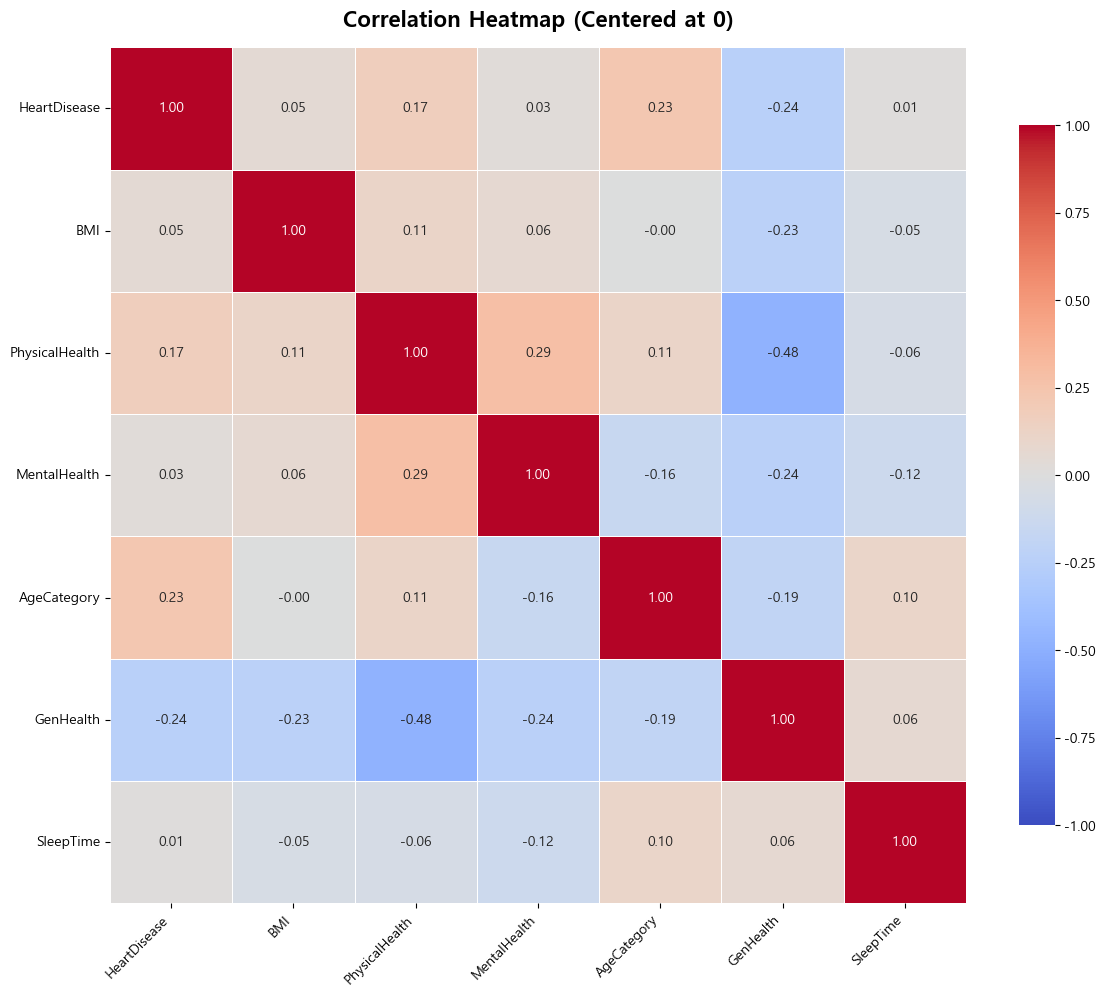

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ 연속형 변수 + 타깃 포함

con_df = df.select_dtypes(include=['float64', 'int64']).copy()

if 'HeartDisease' in df.columns:
    con_df['HeartDisease'] = df['HeartDisease'].astype(float)

# 2️⃣ 상관행렬 계산
corr = con_df.corr()

# 3️⃣ 히트맵 시각화 (0을 중심으로)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',        # 🔵 음의 상관 / 🔴 양의 상관
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True,
    center=0,               # ✅ 색상 중심을 0으로
    vmin=-1, vmax=1         # ✅ 색상 범위를 -1 ~ +1로 고정
)

plt.title('Correlation Heatmap (Centered at 0)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
